### Introduction: CFPB Consumer Complaint Database

#### Purpose and Scope

The **Consumer Financial Protection Bureau (CFPB)** maintains a public database of complaints submitted by consumers regarding financial products and services. Its primary purpose is to provide transparency into the marketplace, allow regulators and researchers to detect systemic issues, and ensure financial institutions respond to consumer grievances in a timely manner.

Complaints are published after companies respond or after 15 days, provided a commercial relationship is confirmed.

#### Complaint Categories and Available Fields

The dataset contains structured tabular metadata combined with unstructured text fields. Key metadata fields include:

* **Product & Sub-product:** Broad and specific financial product classifications (e.g., *Credit reporting*, *Mortgage*, *Debt collection*, *Student loans*).

* **Issue & Sub-issue:** Categorical labels detailing the specific problem (e.g., *Incorrect information on your report*, *Trouble during payment process*).

* **Company Information:** The targeted financial institution and whether their response was timely.

* **Geographic & Temporal Data:** `State`, `ZIP code`, and `Date received`.

* **Consumer Consent & Relational Status:** Flags indicating whether consent was provided to publish the written narrative publicly.

#### The Role of Complaint Narratives in NLP

The `Consumer complaint narrative` field represents raw, unstructured text written by consumers describing their experiences in their own words. Because structured categories (`Product`/`Issue`) are selected via fixed dropdowns, they don't always capture nuances or emerging pain points.

Using Natural Language Processing (NLP) on these narratives allows us to:

* Extract topics and semantic clusters beyond pre-defined categories.
* Build automated text classification models to route or tag complaints.
* Identify recurring patterns, systemic fraud, or sudden policy shifts in real time.
* Perform sentiment and emotion analysis to gauge consumer frustration levels and top     keywords they used from their narrative complaints.


#### Project Focus: 2025 Complaints

While the full CFPB dataset dates back to 2011 and contains millions of records, this notebook focuses specifically on **complaints filed during the calendar year 2025** to perform sentiment and emotion analysis to gauge consumer frustration levels and top     keywords they used from their narrative complaints..

#### Resources & Documentation

* **CFPB Search Interface & Data Source:** [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/)
* **Technical API & Field Definitions:** [CFPB API & Data Reference Dictionary](https://cfpb.github.io/api/ccdb/api.html)

#### Load all requirements

In [1]:
#check python version
!python3 --version

Python 3.12.13


In [1]:
# !pip install pandas numpy
# !pip install -U spacy
# !pip install -U streamlit
# !pip install -U plotly
# !pip install -U matplotlib
# !pip install -U vaderSentiment
# !pip install -U textblob
# !pip install -U wordcloud
# !pip install -U scikit-learn
# !pip install -U sentence-transformers
# !pip install -U bertopic
# !pip install -U transformers
# !pip install -U torch
# !pip install vaderSentiment
# !pip install wordcloud tqdm

In [2]:
import pandas as pd
import argparse
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from spacy.matcher import PhraseMatcher
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter

In [12]:
pd.set_option('display.max_colwidth', None)

#### Loading 2025 complaints dataset

In [33]:
def load_complaints_data(file_name, is_colab=False):
    """Loads the complaints data from either a GitHub path or Google Drive.

    Args:
        file_name (str): The relative path to the CSV file (e.g., "../../data/complaints_in_just_2025.csv").
        is_colab (bool): If True, construct path for Google Drive. Defaults to False.

    Returns:
        pandas.DataFrame: The loaded and cleaned DataFrame.
    """
    if is_colab:
        from google.colab import drive
        import os
        # Mount Google Drive
        drive.mount('/content/drive')

        # Assuming your data folder is directly under MyDrive
        gdrive_base_path = '/content/drive/MyDrive/'
        # Extract just the filename from the original file_name
        base_file_name = os.path.basename(file_name)
        full_path = os.path.join(gdrive_base_path, base_file_name)
    else:
        full_path = file_name

    df = pd.read_csv(full_path, low_memory=False)
    return df

# Load the data, setting is_colab=True since we are in a Colab environment
df = load_complaints_data("../../data/complaints_in_just_2025.csv", is_colab=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
df.shape

(5443005, 16)

In [35]:
#df.head(5)

In [36]:
df.groupby('Product').size().reset_index(name='count').sort_values(
    by='count', ascending=False)

,Product,count
2,Credit reporting or other personal consumer reports,4810314
3,Debt collection,283206
1,Credit card,89989
5,"Money transfer, virtual currency, or money service",84618
0,Checking or savings account,84198
6,Mortgage,24694
9,Student loan,21314
10,Vehicle loan or lease,20771
7,"Payday loan, title loan, personal loan, or advance loan",13135
8,Prepaid card,6499


In [37]:
df.groupby([
    'Product',
    'Sub-product'
]).size().reset_index(name='count').sort_values(by='count', ascending=False)

# Count complaints for each product and sub-product combination.
# Calculate each combination's percentage of all complaints, sort by count, and keep the top 10.
product_counts = (
    df.groupby(['Product', 'Sub-product'])
      .size()
      .reset_index(name='count')
)
product_counts['percentage'] = (
    product_counts['count'] / product_counts['count'].sum() * 100
).round(2)
product_counts.sort_values(by='count', ascending=False).head(10)

,Product,Sub-product,count,percentage
6,Credit reporting or other personal consumer reports,Credit reporting,4792219,88.04
11,Debt collection,I do not know,154408,2.84
4,Credit card,General-purpose credit card or charge card,80557,1.48
1,Checking or savings account,Checking account,70235,1.29
24,"Money transfer, virtual currency, or money service",Domestic (US) money transfer,57854,1.06
14,Debt collection,Other debt,44945,0.83
9,Debt collection,Credit card debt,38636,0.71
54,Vehicle loan or lease,Loan,18104,0.33
7,Credit reporting or other personal consumer reports,Other personal consumer report,18095,0.33
51,Student loan,Federal student loan servicing,17731,0.33


In [38]:
# The 2025 dataset has 5,443,005 rows and 16 columns
# The full dataset has 15,896,496 observations
df.shape

(5443005, 16)

In [39]:
# List the raw data types of all columns of the Pandas data frame
df.dtypes

,0
Date received,object
Product,object
Sub-product,object
Issue,object
Sub-issue,object
Consumer complaint narrative,object
Company public response,object
Company,object
State,object
ZIP code,object


In [40]:
# Convert date columns to datetime and normalize timestamps to midnight (YYYY-MM-DD).
# pd.to_datetime handles both string and already-converted datetime values.
df['Date received'] = pd.to_datetime(
    df['Date received'], errors='coerce').dt.normalize()

df['Date sent to company'] = pd.to_datetime(
    df['Date sent to company'], errors='coerce').dt.normalize()

In [41]:
# Look at a few obs to make sure we have correctly formatformatted date and time.
#df.head()

In [42]:
# Group complaints by year received and count observations
df.groupby(df['Date received'].dt.year).size()

,0
Date received,
2025,5443005


In [60]:
# Group complaints by product category and count observations
df.groupby(df['Product']).size().sort_values(ascending=False).reset_index(name='count')

,Product,count
0,Credit reporting or other personal consumer reports,4810314
1,Debt collection,283206
2,Credit card,89989
3,"Money transfer, virtual currency, or money service",84618
4,Checking or savings account,84198
5,Mortgage,24694
6,Student loan,21314
7,Vehicle loan or lease,20771
8,"Payday loan, title loan, personal loan, or advance loan",13135
9,Prepaid card,6499


In [61]:
# Group complaints by issue category and count observations

df.groupby('Issue').size().sort_values(ascending=False).reset_index(name='count').head(10)

,Issue,count
0,Incorrect information on your report,2834686
1,Improper use of your report,1101582
2,Problem with a company's investigation into an existing problem,867390
3,Attempts to collect debt not owed,115683
4,Written notification about debt,64048
5,Other transaction problem,53893
6,Took or threatened to take negative or legal action,48580
7,Managing an account,44963
8,False statements or representation,38462
9,Problem with a purchase shown on your statement,19814


In [58]:
# Group by the company public response and count obsevations

df.groupby(df['Company public response']).size().sort_values(
    ascending=False).reset_index(name='count')

,Company public response,count
0,Company has responded to the consumer and the CFPB and chooses not to provide a public response,3110144
1,Company believes it acted appropriately as authorized by contract or law,48420
2,Company disputes the facts presented in the complaint,2883
3,Company believes the complaint provided an opportunity to answer consumer's questions,2172
4,Company can't verify or dispute the facts in the complaint,1603
5,Company believes complaint represents an opportunity for improvement to better serve consumers,596
6,Company believes the complaint is the result of a misunderstanding,581
7,Company believes complaint caused principally by actions of third party outside the control or direction of the company,555
8,Company believes complaint is the result of an isolated error,378
9,Company believes complaint relates to a discontinued policy or procedure,8


In [62]:
# Group by company response to consumer and count obsevations

df.groupby(df['Company response to consumer']).size().sort_values(
    ascending=False).reset_index(name='count')

,Company response to consumer,count
0,Closed with explanation,3194212
1,Closed with non-monetary relief,2212222
2,Closed with monetary relief,26109
3,Untimely response,10097
4,In progress,365


In [74]:
# Group by timely response and Company response to consumer to consumer complaints and count obsevations

df.groupby(['Timely response?','Company response to consumer']).size()

Timely response?  Company response to consumer   
No                Closed with explanation              13161
                  Closed with monetary relief            142
                  Closed with non-monetary relief       1195
                  Untimely response                    10097
Yes               Closed with explanation            3181051
                  Closed with monetary relief          25967
                  Closed with non-monetary relief    2211027
                  In progress                            365
dtype: int64

In [75]:
# Count up the number of unique companies having consumer complaints

df['Company'].nunique()

3961

In [76]:
# Find the top 10 companies with the most consumer complaints
df['Company'].value_counts().head(10)

,count
Company,
"EQUIFAX, INC.",1680538
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",1601851
Experian Information Solutions Inc.,1388821
"Block, Inc.",48091
CAPITAL ONE FINANCIAL CORPORATION,34102
"CBC Companies, Inc.",30769
"Early Warning Services, LLC",24509
JPMORGAN CHASE & CO.,24458
Resurgent Capital Services L.P.,23741


### Summary of the data wrangling

**Dataset loading and validation:** Import the required Python libraries and loads the 2025 CFPB complaint file into a pandas DataFrame. Rows without a `Consumer complaint narrative` are removed.

### Key insights

**Credit reporting dominates the dataset.** Credit reporting or other personal consumer reporting complaints account for the largest product category and substantially exceed the other categories. This concentration should be considered when interpreting NLP results because overall themes may primarily reflect credit-reporting experiences.

**Debt collection and money-transfer complaints are also prominent.** These categories form important secondary groups and may reveal distinct issues involving collection practices, payment transfers, and account access.

**Complaint narratives are a valuable source of unstructured information.** Product and issue fields provide structured labels, while the narratives provide consumers' descriptions of events, impacts, and desired resolutions. This may support text classification, topic discovery, and sentiment or outcome analysis.

**Company-response fields enable outcome analysis.** Comparing `Company response to consumer` with `Timely response?` can show whether timely handling is associated with different resolution outcomes. These fields describe reported responses, not necessarily whether the consumer considered the issue fully resolved.

**Company counts may reflect market size as well as complaint frequency.** Companies with the most complaints may serve more customers or offer more products, so complaint volume should not be interpreted as a complaint rate without an appropriate exposure denominator.

**Privacy masking affects text modeling.** CFPB narratives may contain redacted names, dates, account numbers, and other identifying information. These masks should be handled during preprocessing so they do not dominate the vocabulary or create misleading NLP features.

In [30]:
df_2025 = df.copy()
df_2025.rename(
    columns={'Consumer complaint narrative': 'narrative'},
    inplace=True
)

In [31]:
#load modules
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## Data preparation
The CFPB database is massive, but not all entries contain text because consumers must explicitly opt-in to share their narratives.

Here is a step-by-step pipeline to clean, preprocess, and structure this data for Natural Language Processing (NLP).

## Text Preprocessing Pipeline

Consumer complaint narratives are unstructured text and may contain inconsistent capitalization, punctuation, web artifacts, privacy masks, and boilerplate language. Before applying machine-learning models such as TF-IDF with logistic regression or more advanced deep-learning methods, the narratives must be normalized to reduce noise and create a consistent vocabulary.

The preprocessing workflow includes the following steps:

- **Normalize privacy masks:** Standardize CFPB redactions such as `XXXX`, masked dates, and masked dollar amounts so that they are treated consistently rather than as unrelated tokens.

- **Convert text to lowercase:** Make words such as `Credit` and `credit` equivalent, reducing unnecessary vocabulary duplication.

- **Remove web artifacts:** Remove URLs, HTML entities, duplicate whitespace, and other formatting artifacts that do not contribute meaningful information.

- **Remove punctuation and special characters:** Reduce noise while preserving information that may be useful for interpretation.

- **Tokenize the narratives:** Split each narrative into individual words or tokens for analysis.

- **Remove stop words selectively:** Remove frequent words with limited analytical value, but retain negation terms such as `not` and `no` because they can change the meaning of a complaint.

- **Lemmatize words:** Reduce related word forms to a common base form; for example, `charged`, `charging`, and `charges` can be represented by `charge`.

- **Filter uninformative records:** Remove empty, whitespace-only, duplicate, or very short narratives that are unlikely to provide sufficient information for modeling.

This sequence produces cleaner text while preserving important complaint meaning and resolution-related language for downstream NLP analysis.

In [77]:
def normalize_masks(text):
    """Replace CFPB privacy redactions with meaningful standard tokens."""
    # Replace masked dates, such as XX/XXX/XXXXX, with a consistent date token.
    text = re.sub(r'\b[xX]{2}/[xX]{3}/[xX]{4\b', '[MASKED_DATE]', text)
    # Replace masked dollar amounts or numeric values with an amount token.
    text = re.sub(r'\$[xX,]+', '[MASKED_AMOUNT]', text)
    # Replace remaining sequences of two or more x/X characters with a text token.
    text = re.sub(r'[xX]{2,}', '[MASKED_TEXT]', text)
    # Apply the standardized masking function to the complaint narratives.
    text = re.sub(r'X{2,}', '[REDACTED]', text)
    return text

# Create a cleaned text column while preserving the original complaint narrative.
df_2025['cleaned_narrative'] = df_2025['narrative'].apply(normalize_masks)

In [78]:
# Filter out short, non-meaningful descriptions (under 20 words)
df_2025 = df_2025[df_2025['cleaned_narrative'].apply(lambda x: len(str(x).split()) > 20)]

In [79]:
import html

def clean_web_artifacts(text):
    text = html.unescape(text) # Converts &amp; to &
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Removes URLs
    text = re.sub(r'\s+', ' ', text).strip() # Removes duplicate whitespace/newlines
    return text

In [80]:
# Remove web and formatting artifacts from the cleaned complaint narratives.
df_2025['cleaned_narrative'] = df_2025['cleaned_narrative'].apply(clean_web_artifacts)

/tmp/ipykernel_5460/2738558532.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['cleaned_narrative'] = df_2025['cleaned_narrative'].apply(clean_web_artifacts)


#### Grouping shifting categorical targets to ensure text consistency

In [81]:

product_mapping = {
    'Credit card': 'Credit Card/Prepaid',
    'Prepaid card': 'Credit Card/Prepaid',
    'Credit card or prepaid card': 'Credit Card/Prepaid',
}
df_2025['Product_Standardized'] = df_2025['Product'].replace(product_mapping)

/tmp/ipykernel_5460/3789582336.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Product_Standardized'] = df_2025['Product'].replace(product_mapping)


#### Keep only rows where a commercial relationship was verified and sent to the company

In [82]:
# Keep only rows where a commercial relationship was verified and sent to the company
df_2025 = df_2025[df_2025['Submitted via'] != 'Referral']
df_2025 = df_2025.dropna(subset=['Company response to consumer'])

#### Prune Document Length Extremes
Extremely long documents dilate the computational matrix size (especially for deep learning embedding vectors) and dilute the actual "sentiment" signal with thousands of words of standard chronological noise.

In [83]:
# Filter by token-count percentiles
df_2025['word_count'] = df_2025['cleaned_narrative'].apply(lambda x: len(x.split()))
min_thresh = df_2025['word_count'].quantile(0.05)
max_thresh = df_2025['word_count'].quantile(0.95)

df_filtered = df_2025[(df_2025['word_count'] >= min_thresh) & (df_2025['word_count'] <= max_thresh)]

In [84]:
df_filtered.shape

(1055842, 19)

In [85]:
# Map responses to Binary Sentiment/Outcome (1 = Relief/Positive resolution, 0 = No relief)
relief_responses = ['Closed with monetary relief', 'Closed with non-monetary relief']
df_filtered['response_binary'] = df_filtered['Company response to consumer'].apply(lambda x: 1 if x in relief_responses else 0)

/tmp/ipykernel_5460/3065730936.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['response_binary'] = df_filtered['Company response to consumer'].apply(lambda x: 1 if x in relief_responses else 0)


In [86]:
df_filtered.head()

,Date received,Product,Sub-product,Issue,Sub-issue,narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,cleaned_narrative,Product_Standardized,word_count,response_binary
1,2025-04-08,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Account information incorrect,"To Whom It May Concern, I am filing a formal complaint against Mohela, XXXX, XXXX, and XXXX for continued reporting and collection of student loan debt that is now legally void following the executive order to abolish the U.S. Department of Education.\n\nComplaint Details : 1. Illegal Credit Reporting The credit bureaus continue to report student loans that are now unverified and legally questionable due to the dissolution of the Department of Education.\n\n2. Failure to Verify Legitimacy of Debt The loan servicer has failed to provide evidence of legal ownership, collection rights, or servicing obligations in light of the agencys abolishment.\n\n3. Unfair and Deceptive Practices The continued collection of these debts constitutes a violation of my rights under the FCRA ( 15 U.S.C. 1681 ) and FDCPA ( 15 U.S.C. 1692 ).\n\nI demand an immediate investigation, deletion of these accounts from my credit report, and cessation of any collection efforts by my loan servicer. If this matter is not resolved promptly, I will pursue further legal action. \n\nSincerely, XXXX XXXX",NaN,MOHELA,NE,681XX,NaN,Web,2025-04-08,Closed with explanation,No,12856469,"To Whom It May Concern, I am filing a formal complaint against Mohela, [MASKED_TEXT], [MASKED_TEXT], and [MASKED_TEXT] for continued reporting and collection of student loan debt that is now legally void following the executive order to abolish the U.S. Department of Education. Complaint Details : 1. Illegal Credit Reporting The credit bureaus continue to report student loans that are now unverified and legally questionable due to the dissolution of the Department of Education. 2. Failure to Verify Legitimacy of Debt The loan servicer has failed to provide evidence of legal ownership, collection rights, or servicing obligations in light of the agencys abolishment. 3. Unfair and Deceptive Practices The continued collection of these debts constitutes a violation of my rights under the FCRA ( 15 U.S.C. 1681 ) and FDCPA ( 15 U.S.C. 1692 ). I demand an immediate investigation, deletion of these accounts from my credit report, and cessation of any collection efforts by my loan servicer. If this matter is not resolved promptly, I will pursue further legal action. Sincerely, [MASKED_TEXT] [MASKED_TEXT]",Credit reporting or other personal consumer reports,173,0
2,2025-04-15,Student loan,Federal student loan servicing,Struggling to repay your loan,"Problem with forgiveness, cancellation, or discharge","Struggling with a XXXX has significantly impacted my financial stability, making it impossible for me to meet my student loan obligations. The challenges I face daily limit my ability to work consistently or earn a sufficient income, resulting in overwhelming stress and anxiety about my financial future. Despite my efforts to seek assistance and explore repayment options, the burden of student loan debt continues to loom large. I hope for understanding and support from creditors as I navigate this difficult period, seeking solutions that can alleviate the pressure and allow me to focus on my health and well-being.",NaN,"Maximus Federal Services, Inc.",AL,35007,NaN,Web,2026-04-06,Closed with explanation,Yes,12989708,"Struggling with a [MASKED_TEXT] has significantly impacted my financial stability, making it impossible for me to meet my student loan obligations. The challenges I face daily limit my ability to work consistently or earn a sufficient income, resulting in overwhelming stress and anxiety about my financial future. Despite my efforts to seek assistance and explore repayment op

In [89]:
# save the filtered DataFrame to a new CSV file
#This is the same as df_filtered csv file
#df_filtered.to_csv('../../data/complaints_2025_filtered.csv', index=False)

df_filtered.to_csv('/content/drive/MyDrive/complaints_2025_filtered.csv', index=False)

#### SpaCy

In [90]:
df=df_filtered.sample(10000)

In [91]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,cleaned_narrative,Product_Standardized,word_count,response_binary
1829662,2025-05-16,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Earlier today, I found unfamiliar accounts listed on my credit report and I have no explanation for their presence. I routinely review my credit report, but these discrepancies appeared unexpectedly. I attempted to refresh the page in case it was a temporary glitch, but the incorrect accounts remained. Therefore, Im requesting a thorough review of the documents I submitted to ensure this issue is properly addressed.",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33458,NaN,Web,2025-05-16,Closed with non-monetary relief,Yes,13558343,"Earlier today, I found unfamiliar accounts listed on my credit report and I have no explanation for their presence. I routinely review my credit report, but these discrepancies appeared unexpectedly. I attempted to refresh the page in case it was a temporary glitch, but the incorrect accounts remained. Therefore, Im requesting a thorough review of the documents I submitted to ensure this issue is properly addressed.",Credit reporting or other personal consumer reports,66,1
52439,2025-01-06,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"It feels unjust that despite my consistent track record of on-time payments for this account, I find myself in this predicament. I urge you to rectify my account promptly to ensure its accurate representation.",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MI,48083,NaN,Web,2025-01-06,Closed with non-monetary relief,Yes,11405380,"It feels unjust that despite my consistent track record of on-time payments for this account, I find myself in this predicament. I urge you to rectify my account promptly to ensure its accurate representation.",Credit reporting or other personal consumer reports,34,1
1868157,2025-05-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"I have not supplied proof under the doctrine of estoppel by silence, Engelhardt V. Gravens ( MO ) 281 SW 715.719. I pressume that no proof of the alleged debt, nor therefore any such debt, in fact therefore exist.",Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,TX,77396,NaN,Web,2025-05-20,Closed with explanation,Yes,13625060,"I have not supplied proof under the doctrine of estoppel by silence, Engelhardt V. Gravens ( MO ) 281 SW 715.719. I pressume that no proof of the alleged debt, nor therefore any such debt, in fact therefore exist.",Credit reporting or other personal consumer reports,39,0
1660037,2025-05-04,Credit reporting or other personal consumer reports,Credit reporting,Problem with a company's investigation into an existing problem,Their investigation did not fix an error on your report,"I am filing a complaint against Experian for failing to properly investigate my disputes regarding inaccuracies in my credit report. \nDespite my submissions, Experian consistently responds within XXXX hours stating the account is accurate, without providing any evidence of a thorough investigation. \nThis practice violates the Fair Credit Reporting Act ( FCRA ), 15 U.S.C. 1681i, which mandates a reasonable investigation of disputes. Furthermore, Experian actions may also contravene the Consumer Financial Protection Act ( CFPA ), 12 U.S.C. \n5

In [92]:
!python3 -m spacy download en_core_web_sm
!python3 -m spacy download en_core_web_md
!python3 -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 23.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 875.2 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('e

## Sentiment Analysis: VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for short, informal text. It assigns a compound sentiment score ranging from -1 to 1, where values closer to -1 indicate more negative sentiment and values closer to 1 indicate more positive sentiment. The score is calculated from the cleaned complaint narrative and is used to summarize the emotional tone of consumers' descriptions.

Because CFPB complaint narratives are often detailed, formal, and focused on specific financial problems, VADER scores should be interpreted as an indicator of expressed sentiment rather than a direct measure of complaint severity, customer satisfaction, or resolution success.

In [93]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

In [94]:
df["sentiment_vader"] = df["cleaned_narrative"].apply(vader_score)

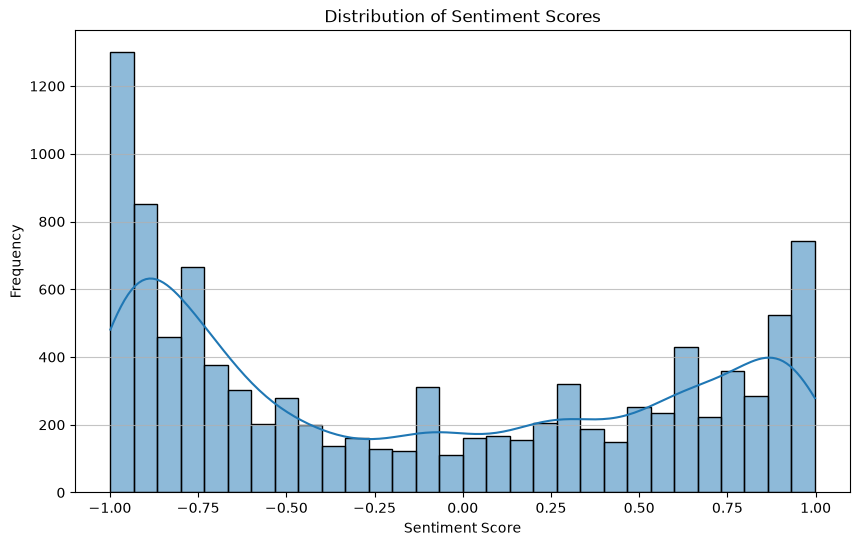

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_vader'], bins=30, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Interpreting the positive VADER scores

A large number of positive VADER scores does not necessarily mean that consumers were satisfied with their financial products or that their complaints were resolved positively. Several factors can explain this pattern:

- **Complaint narratives contain mixed language.** Consumers may describe a negative experience while also using positive words such as `help`, `thank`, `appreciate`, `correct`, or `resolved` when discussing a company representative, a requested outcome, or a partial improvement.

- **VADER is lexicon-based.** VADER assigns sentiment values to individual words and phrases. It may identify positive terms without fully understanding the broader financial context or the complaint's main issue.

- **Narratives often include procedural language.** Words such as `account`, `payment`, `credit`, `service`, and `information` can appear in contexts that are not emotionally positive, but the overall wording may still produce a slightly positive compound score.

- **The cleaned text changes the original writing.** Lowercasing, removing punctuation, filtering tokens, and replacing redacted information can remove emphasis, negation cues, or other context that affects sentiment scoring.

- **A positive score is not the same as a positive outcome.** VADER measures the tone expressed in the narrative; it does not measure whether the consumer received monetary relief, non-monetary relief, or a satisfactory resolution.

Therefore, VADER scores should be interpreted together with the original narrative, product and issue categories, and the company-response fields. They are most useful for comparing broad language patterns across groups rather than classifying individual complaints as resolved or unresolved.

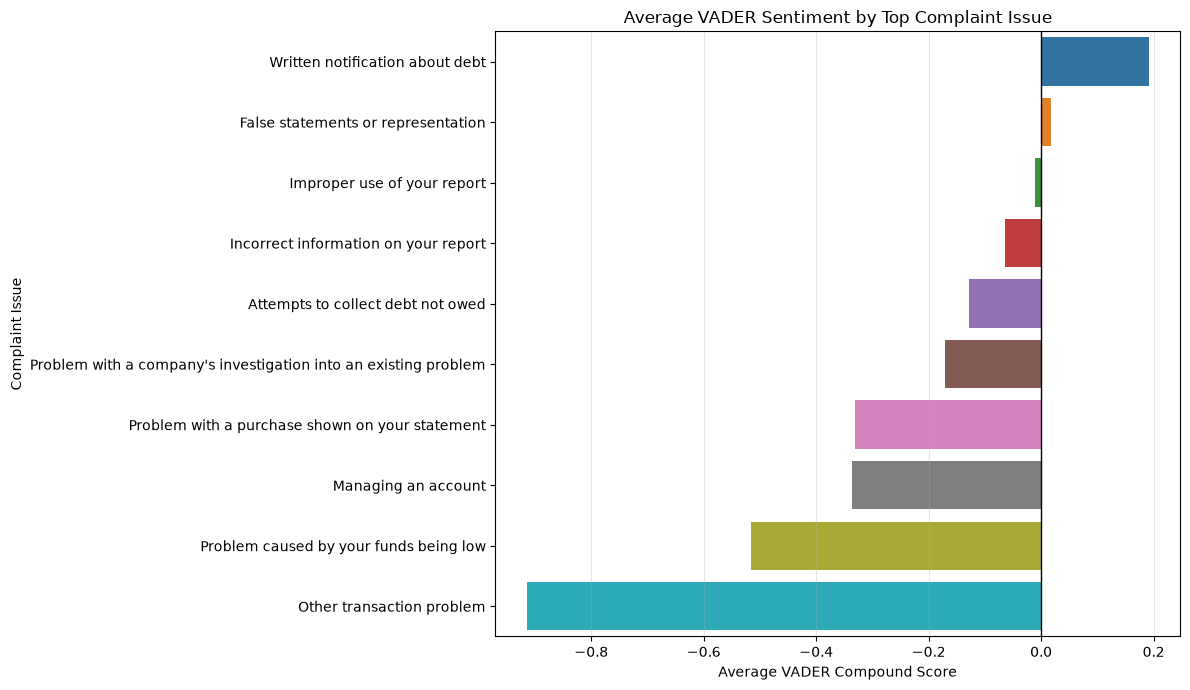

In [96]:
# Compare average VADER sentiment across the 10 most common complaint issues.
top_issues = df['Issue'].value_counts().head(10).index
issue_sentiment = (
    df[df['Issue'].isin(top_issues)]
      .groupby('Issue', as_index=False)['sentiment_vader']
      .mean()
      .sort_values('sentiment_vader', ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=issue_sentiment,
    x='sentiment_vader',
    y='Issue',
    hue='Issue',
    palette='tab10',
    legend=False
)
plt.title('Average VADER Sentiment by Top Complaint Issue')
plt.xlabel('Average VADER Compound Score')
plt.ylabel('Complaint Issue')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Insight for Average VADER Sentiment by Top Complaint Issue Plot

The plot 'Average VADER Sentiment by Top Complaint Issue' provides a comparison of how the emotional tone varies across different types of financial problems reported in 2025. Here is a breakdown of what the visualization reveals:

- **Relative Sentiment Comparison:** The chart ranks the top 10 issues from highest (most positive/neutral) to lowest (most negative) average compound score. A score of 0 represents neutral sentiment.
Negative vs. Positive Leanings: As we noticed issues like 'Other transaction problem' or 'Managing an account' show significantly more negative scores. This typically reflects high consumer frustration regarding lost funds or inaccessible accounts.

- **The 'Neutral' Illusion:** Many issues, particularly 'False statement', might hover near or even slightly above zero. As noted, this doesn't mean the consumers are happy; rather, it often indicates the use of formal, procedural language (e.g., 'I am writing to dispute...') which VADER's general-purpose lexicon flags as neutral or slightly positive.

- **Actionable Insights:** By identifying which issues trigger the most intense negative language, regulators or companies can prioritize these areas for immediate systemic review, as they represent the highest levels of consumer distress.

# Financial Severity Score

In [97]:

nlp = spacy.load("en_core_web_sm")

# Define categories and keyword lists
category_lexicon = {
    # Severity Levels
    "critical": [
        "foreclosure", "eviction", "bankruptcy", "homeless", "sheriff sale",
        "lease termination", "padlock", "shelter", "lawsuit", "garnishment",
        "subpoena", "attorney general", "summons", "court order", "judgment",
        "wage attachment", "poverty", "destitute", "hardship", "suicidal"
    ],
    "high": [
        "fraud", "identity theft", "stolen funds", "scam", "unauthorized transaction",
        "account takeover", "phishing", "impersonation", "wire fraud", "forgery",
        "closed account", "repossession", "collections", "frozen account",
        "seized funds", "account lock", "charge off", "predatory lending", "harassment"
    ],
    "medium": [
        "incorrect reporting", "credit score", "dispute", "fcra", "unverified debt",
        "mixed file", "late fee", "overdraft fee", "hidden charge", "unauthorized fee",
        "interest rate increase", "billing error", "escrow shortage", "double charged"
    ],

    # Domain / Action Types
    "legal_risk": [
        "lawsuit", "attorney", "lawyer", "court", "subpoena", "legal action",
        "suing", "fcra violation", "fdcpa", "tcpa", "regulatory complaint"
    ],
    "financial_loss": [
        "stolen funds", "overdraft fee", "unauthorized charge", "drained account",
        "wire fraud", "double charged", "seized funds", "unauthorized fee"
    ],
    "credit_damage": [
        "credit score dropped", "incorrect reporting", "derogatory mark",
        "late payment reported", "identity theft", "mixed file", "unverified debt"
    ]
}


# Severity Score Function

In [98]:
# Initialize matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

# Register each category into the matcher
for cat_name, terms in category_lexicon.items():
    patterns = [nlp.make_doc(text) for text in terms]
    matcher.add(cat_name, patterns)

In [99]:
def score_multi_category(doc):
    """
    Evaluates a spaCy Doc against registered categories and returns
    counts and calculated severity metrics.
    """
    matches = matcher(doc)

    # Track term hits per category
    cat_counts = {cat: 0 for cat in category_lexicon.keys()}

    for match_id, start, end in matches:
        string_id = nlp.vocab.strings[match_id]  # Category name
        cat_counts[string_id] += 1

    # Calculate Weighted Composite Severity Score
    # Critical = 5 pts | High = 3 pts | Medium = 1 pt
    composite_severity = (
        (cat_counts['critical'] * 5) +
        (cat_counts['high'] * 3) +
        (cat_counts['medium'] * 1)
    )

    # Return dictionary of all scores
    return {
        'count_critical': cat_counts['critical'],
        'count_high': cat_counts['high'],
        'count_medium': cat_counts['medium'],
        'count_legal_risk': cat_counts['legal_risk'],
        'count_financial_loss': cat_counts['financial_loss'],
        'count_credit_damage': cat_counts['credit_damage'],
        'composite_severity_score': composite_severity
    }

# Batch process narratives
# Ensure 'cleaned_narrative' column contains only strings, converting any NaN to empty strings
docs = list(nlp.pipe(df['cleaned_narrative'].fillna(''), disable=["ner", "parser"]))
scores_list = [score_multi_category(doc) for doc in docs]

# Convert results into a DataFrame and combine with main data
score_df = pd.DataFrame(scores_list)
df_scored = pd.concat([df.reset_index(drop=True), score_df], axis=1)

In [126]:
# pd.set_option('display.max_colwidth', None)
# df_scored.query("State == 'AE'").head(5)

In [141]:
#df_scored.head()
state_mapping = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia', 'AS': 'American Samoa', 'GU': 'Guam', 'MP': 'Northern Mariana Islands',
    'PR': 'Puerto Rico', 'VI': 'Virgin Islands', 'AA': 'Armed Forces Americas',
    'AE': 'Armed Forces Europe', 'AP': 'Armed Forces Pacific'
}


In [143]:
# Top States by Severity and Complaint Volume
import plotly.express as px

# Group by State to get both the average severity and the count of complaints
state_stats = (
    df_scored
    .groupby("State")
    ["composite_severity_score"]
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_severity', 'count': 'complaint_count'})
    .sort_values("complaint_count", ascending=True)  # All states included
)

# Map to full state names using the state_mapping dictionary
state_stats['State_name'] = state_stats['State'].map(state_mapping)

# Create a bar chart: X is severity, Y is State_name (sorted by count)
fig = px.bar(
    state_stats,
    title="Average Severity Score by State (Sorted by Complaint Volume)",
    x="avg_severity",
    y="State_name",
    color="complaint_count",
    labels={
        "avg_severity": "Avg Severity Score",
        "complaint_count": "Total Complaints (Sample)",
        "State_name": "State/Territory"
    },
    hover_data=["complaint_count", "avg_severity"],
    orientation="h",
    color_continuous_scale="Viridis"
)

# Ensure all labels are shown and the order matches our sorted dataframe
fig.update_layout(
    yaxis={
        'categoryorder': 'array',
        'categoryarray': state_stats['State_name'],
        'dtick': 1
    },
    height=1200
)
fig.show()

### Plot Insight: top 20 companies by average composite severity score
The bar chart ranks the top 20 companies by average composite severity score, showing which firms receive the most severe complaint language on average. A higher score indicates that a company's complaints contain more critical, high-risk, or financially harmful terms, so the chart helps identify companies with the most severe consumer issues in the sampled 2025 complaints.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
cat_cols = ['count_critical', 'count_high', 'count_medium', 'count_legal_risk', 'count_financial_loss', 'count_credit_damage']

sns.heatmap(df_scored[cat_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Multi-Category Keyword Correlation Heatmap')
plt.show()

In [ ]:
# Calculate total mentions for each category across the dataset
severity_totals = pd.DataFrame({
    'Severity Level': ['Critical', 'High', 'Medium'],
    'Total Mentions': [
        df_scored['count_critical'].sum(),
        df_scored['count_high'].sum(),
        df_scored['count_medium'].sum()
    ]
})

# Plot Total Mentions Bar Chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=severity_totals,
    x='Severity Level',
    y='Total Mentions',
    palette=['#d9534f', '#f0ad4e', '#5bc0de']  # Red, Orange, Blue
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

plt.title('Total Keyword Frequency Across Severity Categories', fontsize=14, pad=15)
plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Total Keyword Occurrences', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:

from collections import Counter

# Additional stop words specific to CFPB
custom_stopwords = {
    "bank","company","account","credit","loan","card",
    "consumer","told","said","would","could","also",
    "one","get","got","even","back","time","called",
    "call","email","letter","know","received","receive"
}

def extract_keywords(text):
    doc = nlp(str(text).lower())

    words = []

    for token in doc:

        if (
            token.is_stop
            or token.is_punct
            or token.is_space
            or token.like_num
        ):
            continue

        if token.lemma_ in custom_stopwords:
            continue

        if token.pos_ in ["NOUN", "PROPN", "ADJ"]:

            if len(token.lemma_) > 2:
                words.append(token.lemma_)

    return words

In [ ]:
issue_keywords = {}

for issue, group in df_scored.groupby("Issue"):

    counter = Counter()

    for text in group["cleaned_narrative"]:

        counter.update(extract_keywords(text))

    issue_keywords[issue] = counter

for issue, counter in issue_keywords.items():

    print("\n", issue)
    print(counter.most_common(20))

In [ ]:
from wordcloud import WordCloud

for issue, counter in issue_keywords.items():

    wc = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        colormap="tab20"
    )

    wc.generate_from_frequencies(dict(counter))

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(issue, fontsize=18)
    plt.show()

In [ ]:
rows = []

for issue, counter in issue_keywords.items():

    for word, freq in counter.most_common(20):

        rows.append({
            "Issue": issue,
            "Keyword": word,
            "Frequency": freq
        })

top20 = pd.DataFrame(rows)

top20.to_csv("Top20_Keywords_By_Issue.csv", index=False)

top20.head()